# Goals of this analysis
The graphs we are trying to generate
1. Initial distribution of computing time
2. Distribution of computing time after splitting on user device computation time out
3. Distribution of computing time after removing running proof generating in parallel 

We also need to see how long each of these steps take for 5 million votes. And we need to see how long the final time is when we start to speed up message processing.

# How to get the data
Setup the three files to collect the runs you want.
```
__custom_benchmarks__/initial_proof_gen_work.ts
__custom_benchmarks__/split_out_client_side_work.ts
__custom_benchmarks__/parallelized_proof_gen.ts
__custom_benchmarks__/invalid_votes.ts
```

Run them with the following commands
```
yarn run proof_bench_1
yarn run proof_bench_2
yarn run proof_bench_3
yarn run invalid_votes
```

Move the generated json files to a separate folder for analysis.

Enter the file names below

In [32]:
PROOF_BENCH_1_OUTPUT_FILE = "Profile_initial_proof_gen_work.json"
PROOF_BENCH_2_OUTPUT_FILE = "Profile_split_out_client_side_work.json"
PROOF_BENCH_3_OUTPUT_FILE = "Profile_parallelized_proof_gen.json"

INVALID_VOTES_OUTPUT_FILE = "Profile_invalid_votes.json"

Plotting bench 1 and 2 for the report

Saved plot to /Users/joshuab/Software/Uni/ENGGEN700/maci/packages/contracts/final_python_visualisations/images/Profile_split_out_client_side_work_stacked_area.png


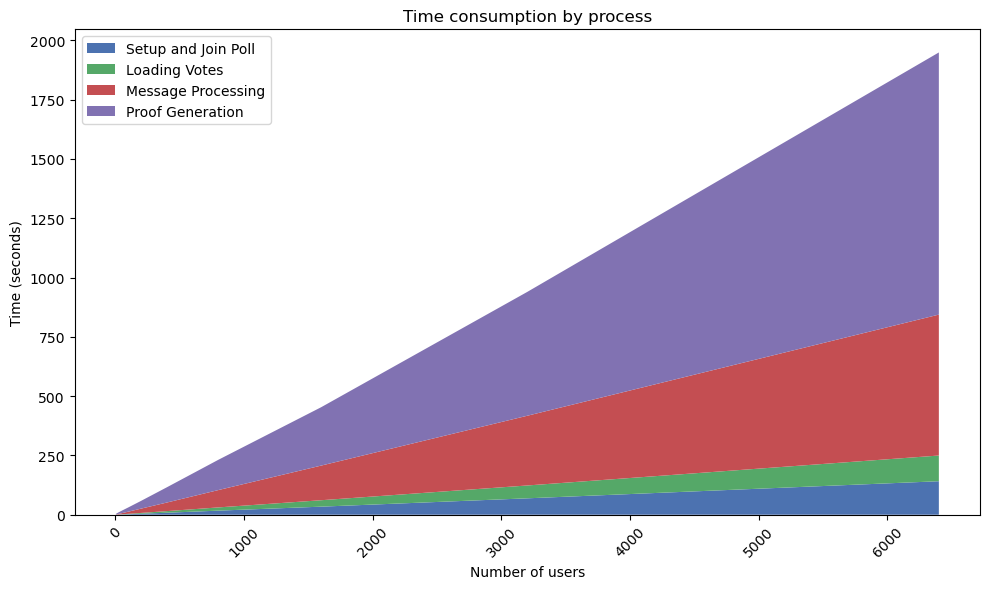

Saved combined pies to /Users/joshuab/Software/Uni/ENGGEN700/maci/packages/contracts/final_python_visualisations/images/Profile_split_out_client_side_work_two_pies.svg


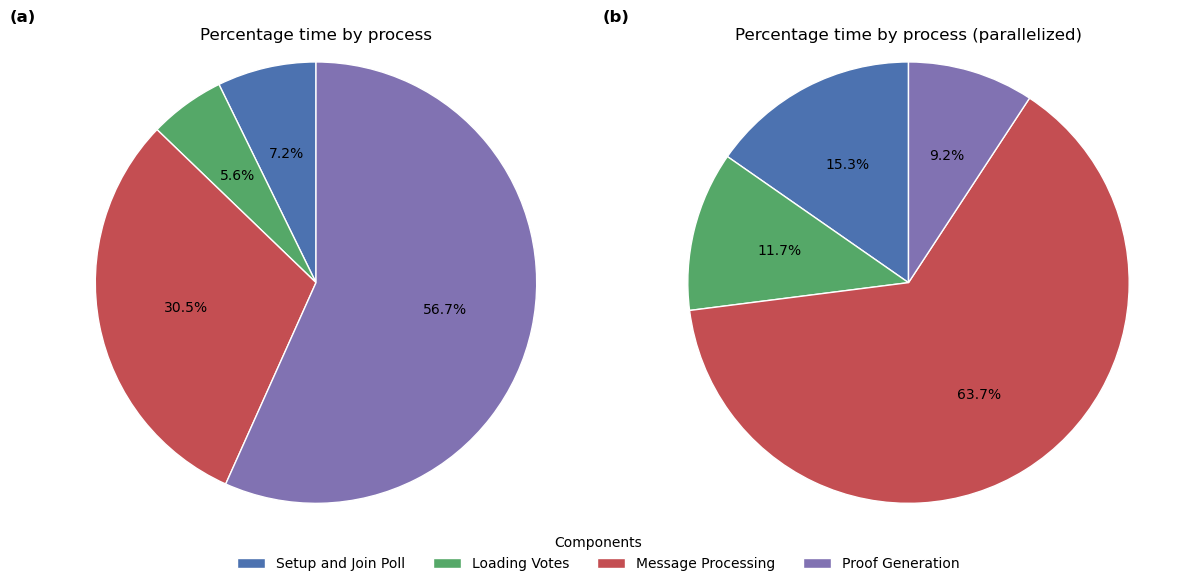

In [33]:
#!/usr/bin/env python3
import json
import sys
from pathlib import Path
from typing import Dict, List, Iterable, Tuple

import matplotlib.pyplot as plt
from matplotlib.patches import Patch


NICE_COLORS = [
    "#4C72B0",  # muted blue
    "#55A868",  # soft green
    "#C44E52",  # brick red
    "#8172B2",  # purple-gray
    "#CCB974",  # mustard
    "#64B5CD",  # teal
    "#8C8C8C",  # neutral gray
]

# ------------- I/O -------------

def load_results(path: Path):
    """Load and return the parsed JSON dict."""
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


# ------------- Grouping helpers -------------

def _normalize_sections(sections_or_fields: Dict, sample_record: dict) -> Tuple[List[List[str]], List[str]]:
    """
    Accepts either:
      1) New grouped style:
         {
           "Compute (CPU+GPU)": ["cpuTime", "gpuTime"],
           "I/O": ["diskTime", "netTime"],
           "Overhead": "overheadTime",
         }
      2) Back-compat (old 'fields' style: key->label, no grouping):
         {
           "cpuTime": "CPU",
           "gpuTime": "GPU",
           ...
         }

    Returns:
        groups: list of lists of raw keys (each inner list is summed into one series)
        labels: list of legend labels (same order as groups)
    """
    # Detect style: if any value is a list or a single known key string (not a label),
    # we assume the *new grouped* style (title -> raw key(s)).
    # Otherwise we assume old style (raw key -> label).
    # Heuristic: check whether dict values are list/str AND those strings look like keys in record.
    record_keys = set(k for k in sample_record.keys() if k != "data")

    def looks_like_key(v: str) -> bool:
        return v in record_keys

    is_grouped = any(
        isinstance(v, (list, tuple)) or (isinstance(v, str) and looks_like_key(v))
        for v in sections_or_fields.values()
    )

    groups: List[List[str]] = []
    labels: List[str] = []

    if is_grouped:
        # New style: title -> key(s)
        for title, keys in sections_or_fields.items():
            if isinstance(keys, str):
                keys = [keys]
            keys = list(keys)
            # Validate keys exist; warn if missing
            missing = [k for k in keys if k not in record_keys]
            if missing:
                print(f"Warning: Missing keys in data for group '{title}': {missing}")
            # Keep only existing keys to avoid KeyError
            keys = [k for k in keys if k in record_keys]
            if not keys:
                # Skip empty groups entirely
                continue
            groups.append(keys)
            labels.append(title)
    else:
        # Old style: rawKey -> label
        for raw_key, label in sections_or_fields.items():
            if raw_key not in record_keys:
                print(f"Warning: Missing key in data: '{raw_key}'")
                continue
            groups.append([raw_key])
            labels.append(label)

    if not groups:
        raise ValueError("No valid groups/fields found after normalization.")
    return groups, labels


def _sum_series_for_group(records: Iterable[dict], keys: List[str]) -> List[float]:
    """Sum multiple fields for each record to produce one series."""
    out = []
    for rec in records:
        total = 0.0
        for k in keys:
            total += rec.get(k, 0.0)
        out.append(total)
    return out


# ------------- Data shaping -------------

def _flatten_results(results: dict):
    """
    Returns:
        flat: list of (numUsers, record) sorted by numUsers asc
    """
    flat = [(rec["data"]["numUsers"], rec) for rec in results.values()]
    flat.sort(key=lambda t: t[0])
    return flat


def extract_series_grouped(results: dict, groups: List[List[str]]):
    """
    Return:
        x      : list[int]    – number of users
        stacks : list[list]   – each inner list holds the summed series for a group
    """
    flat = _flatten_results(results)
    x = [num for num, _ in flat]
    records = [rec for _, rec in flat]
    stacks = [_sum_series_for_group(records, keys) for keys in groups]
    return x, stacks


# ------------- Plotting -------------

def plot(filename, title, sections_or_fields: Dict):
    """
    Draw a stacked area chart.

    Args:
        filename: path to JSON results
        title: chart title
        sections_or_fields:
           - New grouped style: {"Legend Title": ["rawKey1", "rawKey2"], ...}
           - Back-compat:       {"rawKey": "Legend Title", ...}
    """
    json_path = Path(filename)
    if not json_path.exists():
        print(f"Error: file {json_path} does not exist.")
        sys.exit(1)

    results = load_results(json_path)

    # Use the first record to infer key style
    sample_record = next(iter(results.values()))
    groups, labels = _normalize_sections(sections_or_fields, sample_record)

    x, stacks = extract_series_grouped(results, groups)

    # plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.stackplot(x, stacks, labels=labels, colors=NICE_COLORS[: len(labels)])
    ax.set_title(title)
    ax.set_xlabel("Number of users")
    ax.set_ylabel("Time (seconds)")
    ax.legend(loc="upper left")

    ax.tick_params(axis="x", rotation=45)

    out_png = Path("images") / json_path.with_name(json_path.stem + "_stacked_area.png")
    plt.tight_layout()
    plt.savefig(out_png, dpi=600)
    print(f"Saved plot to {out_png.resolve()}")
    plt.show()


def find_record_by_users(results: dict, num_users: int):
    """Return the record with the specified numUsers value, or None if not found."""
    for rec in results.values():
        if rec["data"]["numUsers"] == num_users:
            return rec
    return None


def _labels_and_values_for(filename: str, sections_or_fields: Dict, num_users: int):
    """Helper: returns (labels, values) for a given file and num_users."""
    json_path = Path(filename)
    if not json_path.exists():
        print(f"Error: file {json_path} does not exist.")
        sys.exit(1)

    results = load_results(json_path)
    record = find_record_by_users(results, num_users)
    if record is None:
        print(f"Error: No record found for numUsers={num_users}.")
        sys.exit(1)

    groups, labels = _normalize_sections(sections_or_fields, record)
    values = []
    for keys in groups:
        total = 0.0
        for k in keys:
            total += record.get(k, 0.0)
        values.append(total)
    return labels, values


def plot_pies_side_by_side(
    left,   # (filename, sections_or_fields, num_users, title)
    right,  # (filename, sections_or_fields, num_users, title)
    figure_title: str | None = None,
):
    """
    Draw two pie charts next to each other with a shared legend.
    Labels subplots as (a) and (b), and keeps legend outside the pies.
    """
    (file1, sect1, users1, title1) = left
    (file2, sect2, users2, title2) = right

    labels1, values1 = _labels_and_values_for(file1, sect1, users1)
    labels2, values2 = _labels_and_values_for(file2, sect2, users2)

    # Build a stable union of labels so colors are consistent across both pies.
    unified_labels: List[str] = []
    for L in (labels1, labels2):
        for lab in L:
            if lab not in unified_labels:
                unified_labels.append(lab)

    # Map each label to a color (cycled if needed).
    color_map = {lab: NICE_COLORS[i % len(NICE_COLORS)] for i, lab in enumerate(unified_labels)}

    def autopct_func(pct):
        return f"{pct:.1f}%" if pct >= 4 else ""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    wedges1, _, autotexts1 = ax1.pie(
        values1,
        colors=[color_map[l] for l in labels1],
        startangle=90,
        autopct=autopct_func,
        wedgeprops=dict(linewidth=1, edgecolor="white"),
    )
    ax1.set_title(title1)
    ax1.axis("equal")
    ax1.text(-0.05, 1.05, "(a)", transform=ax1.transAxes, fontsize=12, fontweight="bold", va="bottom")

    wedges2, _, autotexts2 = ax2.pie(
        values2,
        colors=[color_map[l] for l in labels2],
        startangle=90,
        autopct=autopct_func,
        wedgeprops=dict(linewidth=1, edgecolor="white"),
    )
    ax2.set_title(title2)
    ax2.axis("equal")
    ax2.text(-0.05, 1.05, "(b)", transform=ax2.transAxes, fontsize=12, fontweight="bold", va="bottom")

    # Single shared legend below the charts (no overlap).
    legend_handles = [Patch(facecolor=color_map[l], edgecolor="white") for l in unified_labels]
    fig.legend(
        legend_handles,
        unified_labels,
        title="Components",
        loc="lower center",
        ncol=min(4, len(unified_labels)),
        frameon=False,
    )

    if figure_title:
        fig.suptitle(figure_title, y=0.98)

    # Leave room at the bottom for the legend and tighten.
    fig.subplots_adjust(bottom=0.20)
    plt.tight_layout(rect=[0, 0.08, 1, 0.97])

    # Save next to the first file by default.
    out_png = Path("images") / Path(file1).with_name(Path(file1).stem + "_two_pies.svg")
    plt.savefig(out_png, dpi=300, transparent=True, format="svg")
    print(f"Saved combined pies to {out_png.resolve()}")
    plt.show()

PROOF_BENCH_2_TITLE = "Time consumption by process"
PROOF_BENCH_2_FIELDS = {
    "Setup and Join Poll" : ["SIGN_UP", "UPDATE_POLL", "JOIN_POLL"],
    "Loading Votes": ["TOTAL_VALID_VOTES"],
    "Message Processing": ["PROCESS_MESSAGES"],
    "Proof Generation": ["TALLY_PROOFS"],
}
plot(PROOF_BENCH_2_OUTPUT_FILE, PROOF_BENCH_2_TITLE, PROOF_BENCH_2_FIELDS)

PARALLEL_BENCH_FIELDS = PROOF_BENCH_2_FIELDS.copy()
del PARALLEL_BENCH_FIELDS["Proof Generation"]
PARALLEL_BENCH_FIELDS["Proof Generation"] = ["SAVE_CIRCUIT_INPUTS"]

plot_pies_side_by_side(
    left=(
        PROOF_BENCH_2_OUTPUT_FILE,
        PROOF_BENCH_2_FIELDS,
        6400,
        "Percentage time by process",
    ),
    right=(
        PROOF_BENCH_3_OUTPUT_FILE,
        PARALLEL_BENCH_FIELDS,
        6400,
        "Percentage time by process (parallelized)",
    ),
    figure_title=None,  # or set a common title string if you want
)

Saved: /Users/joshuab/Software/Uni/ENGGEN700/maci/packages/contracts/final_python_visualisations/images/total_time_vs_users.svg


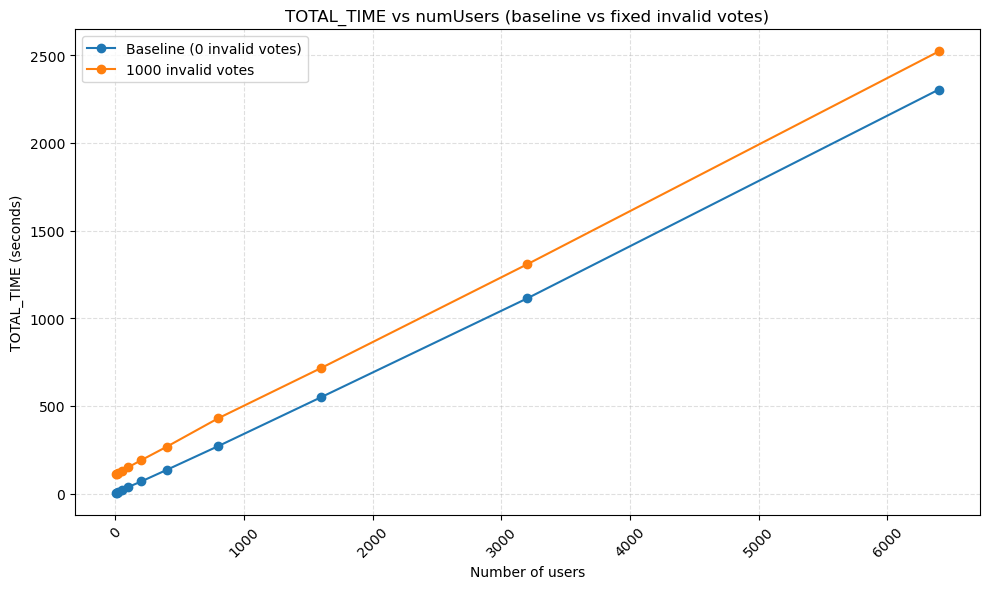


numUsers | baseline(s) | invalid(s) | Δ(s) | Δ%
---------|-------------|------------|------|----
       5 |       4.929 |    111.840 | 106.911 | 2168.9%
      10 |       5.766 |    112.497 | 106.731 | 1851.2%
      20 |       9.718 |    118.020 | 108.302 | 1114.5%
      50 |      19.703 |    130.024 | 110.321 | 559.9%
     100 |      37.141 |    150.102 | 112.962 | 304.1%
     200 |      68.568 |    189.820 | 121.252 | 176.8%
     400 |     135.287 |    267.369 | 132.082 | 97.6%
     800 |     270.672 |    429.498 | 158.826 | 58.7%
    1600 |     549.791 |    716.239 | 166.448 | 30.3%
    3200 |    1112.818 |   1307.246 | 194.428 | 17.5%
    6400 |    2304.173 |   2521.638 | 217.465 |  9.4%


In [34]:
# ------------- TOTAL_TIME vs numUsers (baseline vs fixed invalid votes) -------------

from pathlib import Path
import matplotlib.pyplot as plt

def _series_from_results(results: dict, invalid_votes: int | None):
    """
    Build (x, y) where:
      - x = sorted numUsers
      - y = TOTAL_TIME
    If invalid_votes is None => baseline (numInvalidVotes == 0 or missing)
    If invalid_votes is an int => filter for exactly that count.
    """
    items = []
    for key, rec in results.items():
        meta = rec.get("data", {})
        n_users = meta.get("numUsers")
        inv = meta.get("numInvalidVotes", 0)

        # If numUsers missing, skip
        if n_users is None:
            continue

        if invalid_votes is None:
            # Treat missing numInvalidVotes as baseline
            if inv == 0:
                items.append((n_users, rec.get("TOTAL_TIME", 0.0)))
        else:
            if inv == invalid_votes:
                items.append((n_users, rec.get("TOTAL_TIME", 0.0)))

    items.sort(key=lambda t: t[0])
    x = [n for n, _ in items]
    y = [t for _, t in items]
    return x, y

def _load_results_maybe(path_or_none: str | None):
    if not path_or_none:
        return None
    p = Path(path_or_none)
    if not p.exists():
        raise FileNotFoundError(f"File not found: {p}")
    return load_results(p)

def plot_total_time_vs_users(
    file_with_both: str | None = None,
    file_baseline: str | None = None,
    file_invalids: str | None = None,
    fixed_invalid_votes: int = 1000,
    title: str = "TOTAL_TIME vs numUsers (baseline vs fixed invalid votes)"
):
    """
    Preferred use:
      - If you have a single JSON that includes both baselines and entries like
        '..._1000_invalid_votes', pass it as file_with_both.
      - If you keep baseline and '1000 invalids' in separate files, pass them via
        file_baseline and file_invalids.

    Exactly one of (file_with_both) or (file_baseline + file_invalids) must be provided.
    """
    if file_with_both:
        results = _load_results_maybe(file_with_both)
        if results is None:
            raise ValueError("file_with_both path is required when used.")
        x_base, y_base = _series_from_results(results, invalid_votes=None)
        x_inv, y_inv = _series_from_results(results, invalid_votes=fixed_invalid_votes)
    else:
        if not (file_baseline and file_invalids):
            raise ValueError("Provide either file_with_both OR both file_baseline and file_invalids.")
        res_base = _load_results_maybe(file_baseline)
        res_inv  = _load_results_maybe(file_invalids)
        x_base, y_base = _series_from_results(res_base, invalid_votes=None)
        x_inv,  y_inv  = _series_from_results(res_inv, invalid_votes=fixed_invalid_votes)

    # Make a single line chart with both series
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_base, y_base, marker="o", label="Baseline (0 invalid votes)")
    ax.plot(x_inv,  y_inv,  marker="o", label=f"{fixed_invalid_votes} invalid votes")

    ax.set_title(title)
    ax.set_xlabel("Number of users")
    ax.set_ylabel("TOTAL_TIME (seconds)")
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    out_png = Path("images") / Path((file_with_both or file_baseline)).with_name("total_time_vs_users.svg")
    plt.savefig(out_png, dpi=300, transparent=True, format="svg")
    print(f"Saved: {out_png.resolve()}")
    plt.show()

    # Print a quick side-by-side comparison where both series share the same numUsers
    base_map = {n:t for n, t in zip(x_base, y_base)}
    inv_map  = {n:t for n, t in zip(x_inv,  y_inv)}
    shared = sorted(set(base_map.keys()) & set(inv_map.keys()))
    if shared:
        print("\nnumUsers | baseline(s) | invalid(s) | Δ(s) | Δ%")
        print("---------|-------------|------------|------|----")
        for n in shared:
            b = base_map[n]
            i = inv_map[n]
            delta = i - b
            pct = (delta / b * 100.0) if b else float("inf")
            print(f"{n:8d} | {b:11.3f} | {i:10.3f} | {delta:5.3f} | {pct:4.1f}%")
    else:
        print("No overlapping numUsers between baseline and invalid-votes series to compare.")

plot_total_time_vs_users(
    file_with_both=INVALID_VOTES_OUTPUT_FILE,
    fixed_invalid_votes=1000
)

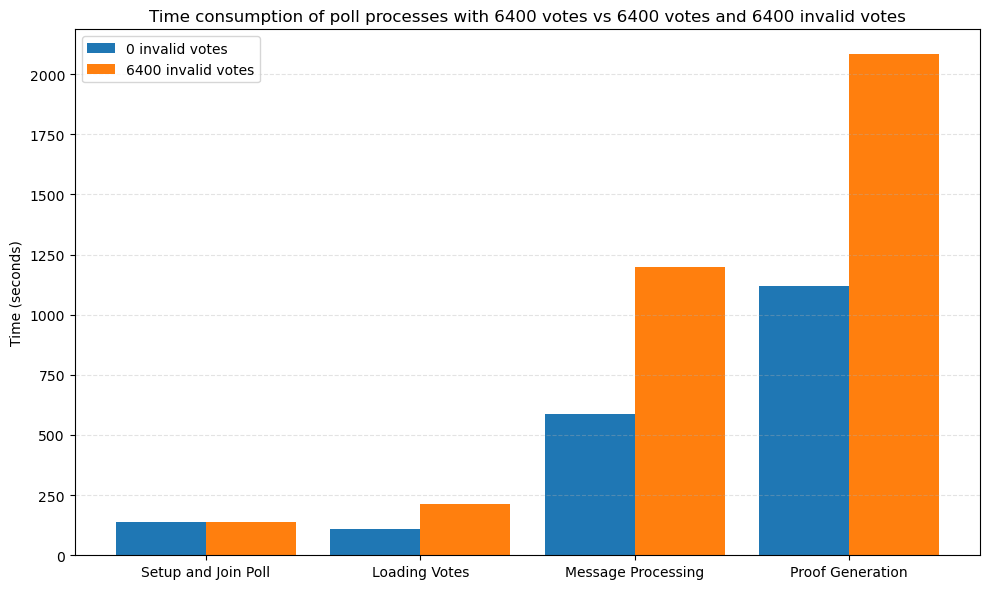

Group                         | A (s)         | B (s)         | Δ (B-A)       | Ratio (B/A)
-----------------------------|---------------|---------------|---------------|------------
Setup and Join Poll           |    140.044343 |    140.216893 |      0.172550 |      1.001
Loading Votes                 |    107.196773 |    214.176494 |    106.979721 |      1.998
Message Processing            |    585.647775 |   1196.721510 |    611.073736 |      2.043
Proof Generation              |   1117.605795 |   2082.219494 |    964.613699 |      1.863


In [35]:
import matplotlib.pyplot as plt

# Extracted from Invalid votes benchmark JSON. One with 6400 valid votes and 0 invalid votes, and the other with 6400 valid votes and 6400 invalid votes.
run_0_invalid = {
    "SIGN_UP": 84.75087879200001,
    "DEPLOY_POLL": 0.0021327919999999997,
    "UPDATE_POLL": 35.932584541999994,
    "JOIN_POLL": 19.360880042,
    "TOTAL_VALID_VOTES": 107.196765834,
    "TOTAL_INVALID_VOTES": 0.000007375,
    "PROCESS_MESSAGES": 585.6477745000001,
    "MP_PROOFS": 0.470441167,
    "TALLY_PROOFS": 1117.605795042,
    "TOTAL_TIME": 2304.172846458,
}

run_6400_invalid = {
    "SIGN_UP": 84.915131833,
    "DEPLOY_POLL": 0.001710292,
    "UPDATE_POLL": 35.971471375,
    "JOIN_POLL": 19.330290249999997,
    "TOTAL_VALID_VOTES": 107.080823958,
    "TOTAL_INVALID_VOTES": 107.095670333,
    "PROCESS_MESSAGES": 1196.721510417,
    "MP_PROOFS": 0.51912775,
    "TALLY_PROOFS": 2082.219493917,
    "TOTAL_TIME": 4341.597216416,
}

# ===== 2) Configure your grouped fields and chart title/labels =====
TITLE = "Time consumption of poll processes with 6400 votes vs 6400 votes and 6400 invalid votes"
FIELDS = {
    "Setup and Join Poll" : ["SIGN_UP", "UPDATE_POLL", "JOIN_POLL"],
    "Loading Votes": ["TOTAL_VALID_VOTES", "TOTAL_INVALID_VOTES"],
    "Message Processing": ["PROCESS_MESSAGES"],
    "Proof Generation": ["TALLY_PROOFS"],
}
SERIES_A_LABEL = "0 invalid votes"
SERIES_B_LABEL = "6400 invalid votes"

# ===== Helper functions =====
def sum_group(record: dict, keys: list[str], *, group_name: str = "") -> float:
    total = 0.0
    for k in keys:
        if k not in record:
            print(f"Warning: '{k}' missing in record for group '{group_name}'. Using 0.")
        total += record.get(k, 0.0)
    return total

def build_group_series(record: dict, groups: dict[str, list[str]]) -> tuple[list[str], list[float]]:
    labels = list(groups.keys())
    values = [sum_group(record, groups[name], group_name=name) for name in labels]
    return labels, values

# ===== Build grouped values for both runs =====
group_labels, series_a = build_group_series(run_0_invalid, FIELDS)
_,            series_b = build_group_series(run_6400_invalid, FIELDS)

# ===== Plot side-by-side bars =====
x = range(len(group_labels))
width = 0.42

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], series_a, width=width, label=SERIES_A_LABEL)
plt.bar([i + width/2 for i in x], series_b, width=width, label=SERIES_B_LABEL)
plt.xticks(x, group_labels, rotation=0)
plt.ylabel("Time (seconds)")
plt.title(TITLE)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("images/time_comparison_bars.svg", dpi=300, transparent=True, format="svg")
plt.show()

# ===== Optional: print a quick comparison table with deltas and ratios =====
print("Group                         | A (s)         | B (s)         | Δ (B-A)       | Ratio (B/A)")
print("-----------------------------|---------------|---------------|---------------|------------")
for name, a, b in zip(group_labels, series_a, series_b):
    delta = b - a
    ratio = (b / a) if a else float("inf")
    print(f"{name:29s} | {a:13.6f} | {b:13.6f} | {delta:13.6f} | {ratio:10.3f}")

# Now extrapolate to 5 million votes

In [36]:
NUM_VOTES_TO_USE_AS_INPUT = 50

def print_seconds(seconds: float):
    print(f"{seconds / 86400:.2f} days")
    print(f"Or about {seconds / 604800:.2f} weeks")

def extrapolate_to_n_votes(
    filename: str,
    sections_or_fields: dict,
    n: int,
    modifiers: dict | None = None,
    base_users: int = NUM_VOTES_TO_USE_AS_INPUT,
):
    """
    Extrapolate grouped timings from a baseline numUsers record up to n votes.

    - sections_or_fields can be in the new grouped style:
        {"Group Title": ["RAW_KEY1", "RAW_KEY2"], ...}
      (back-compat old style is also accepted by _normalize_sections)
    - modifiers is an optional dict of per-raw-key multipliers,
      e.g. {"PROCESS_MESSAGES": 1/1.5} to model a 1.5x speedup.
    """
    modifiers = modifiers or {}
    results = load_results(Path(filename))

    # Find the baseline record (e.g., 50 votes)
    record = find_record_by_users(results, base_users)
    if record is None:
        raise ValueError(f"Could not find data for numUsers={base_users} in {filename}")

    # Normalize to grouped keys (lists of raw keys) and matching labels
    groups, labels = _normalize_sections(sections_or_fields, record)

    # Compute base totals per group with optional per-raw-key modifiers
    base_totals = []
    for keys in groups:
        total = 0.0
        for k in keys:
            val = record.get(k, 0.0)
            mult = modifiers.get(k, 1.0)
            total += val * mult
        base_totals.append(total)

    # Scale linearly from baseline users -> n
    scale_factor = n / float(base_users)
    extrapolated_stack = [v * scale_factor for v in base_totals]
    return n, extrapolated_stack


# --- Define grouped fields for extrapolation ---

# Start from your grouped definition in block one
EXTRAPOLATE_FIELDS = PROOF_BENCH_2_FIELDS.copy()
# Add the extra raw key as its own group (title -> [rawKey])
EXTRAPOLATE_FIELDS["Message processing proofs"] = ["MP_PROOFS"]

n, extrapolated_stack = extrapolate_to_n_votes(
    PROOF_BENCH_2_OUTPUT_FILE,
    EXTRAPOLATE_FIELDS,
    5_000_000,
)
print(f"Non Parallel Time for {n} votes:")
non_parallel_seconds = sum(extrapolated_stack)
print_seconds(non_parallel_seconds)


# Parallel variant: drop tally proofs group; add circuit prep group
PARALLEL_EXTRAPOLATE_FIELDS = EXTRAPOLATE_FIELDS.copy()
# Remove the whole "Proof Generation" group (which contained ["TALLY_PROOFS"])
if "Proof Generation" in PARALLEL_EXTRAPOLATE_FIELDS:
    del PARALLEL_EXTRAPOLATE_FIELDS["Proof Generation"]
# Add the new group mapping to its raw key
PARALLEL_EXTRAPOLATE_FIELDS["Prepare proof circuit inputs"] = ["SAVE_CIRCUIT_INPUTS"]

n, parallel_extrapolated_stack = extrapolate_to_n_votes(
    PROOF_BENCH_3_OUTPUT_FILE,
    PARALLEL_EXTRAPOLATE_FIELDS,
    5_000_000,
)
print(f"\nParallel Time for {n} votes:")
parallel_seconds = sum(parallel_extrapolated_stack)
print_seconds(parallel_seconds)


def process_messages_speedup(speedup: float):
    """
    Apply a speedup multiplier to the raw key 'PROCESS_MESSAGES' inside the grouped
    structure, then recompute the extrapolated total for 5,000,000 votes.
    """
    modifiers = {"PROCESS_MESSAGES": 1.0 / speedup}
    n, modified_parallel_extrapolated_stack = extrapolate_to_n_votes(
        PROOF_BENCH_3_OUTPUT_FILE,
        PARALLEL_EXTRAPOLATE_FIELDS,
        5_000_000,
        modifiers=modifiers,
    )
    print(f"\n{speedup}x message processing time for {n} votes:")
    parallel_seconds = sum(modified_parallel_extrapolated_stack)
    print_seconds(parallel_seconds)
    return parallel_seconds


process_messages_speedup(1.5)
process_messages_speedup(2.0)
process_messages_speedup(3.0)
process_messages_speedup(4.0)
process_messages_speedup(5.0)


Non Parallel Time for 5000000 votes:
20.05 days
Or about 2.86 weeks

Parallel Time for 5000000 votes:
8.89 days
Or about 1.27 weeks

1.5x message processing time for 5000000 votes:
7.15 days
Or about 1.02 weeks

2.0x message processing time for 5000000 votes:
6.29 days
Or about 0.90 weeks

3.0x message processing time for 5000000 votes:
5.42 days
Or about 0.77 weeks

4.0x message processing time for 5000000 votes:
4.98 days
Or about 0.71 weeks

5.0x message processing time for 5000000 votes:
4.72 days
Or about 0.67 weeks


408172.66250000003